<h1 align="center">Support Ticket Classifier</h1>

# Business Problem

My department, a Service Desk organization for a large bank, creates knowledge articles which contain solutions to customer questions and issues. However, many of our agents have difficulty categorizing knowledge articles correctly when they create them. For my term project, I'll be building a model to predict the category or topic that a new knowledge article belongs to based the words that are used in the description of the customer's problem or question. I plan to use the knowledge I gain from this project to create similar models to assist with my work department.

Because I was unable to find data that represented the exact problem that I am trying to solve, I will instead be using a [Customer Support Tickets Dataset](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset) that I obtained from Kaggle. This dataset contains a feature called `Ticket Subject`, which will be my Target for the project and is what I will use to represent the topic of knowledge that a customer's issue falls under. The features will consist of the text from the `Ticket Description` column, which is a plain-text field where an agent or customer can describe the issue. I plan to use NLTK for tokdenizing, removing stopwords, and stemming the words in from the `Ticket Description`s in order to turn the words into features for the analysis.

Since this analysis is a classification problem where each observation should fit into only 1 category and there are more than 2 categories, I plan to utilize some sort of multi-class classification model. I may test and compare several models in order to determine the best one from the problem. 

# Data Exploration

I will be using the [Customer Support Tickets Dataset](https://www.kaggle.com/datasets/suraj520/customer-support-ticket-dataset) from Kaggle.

In [21]:
import pandas as pd

# Read in the csv file
df = pd.read_csv('customer_support_tickets.csv')

# Preview the data
df.tail()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN


##### Graph 1

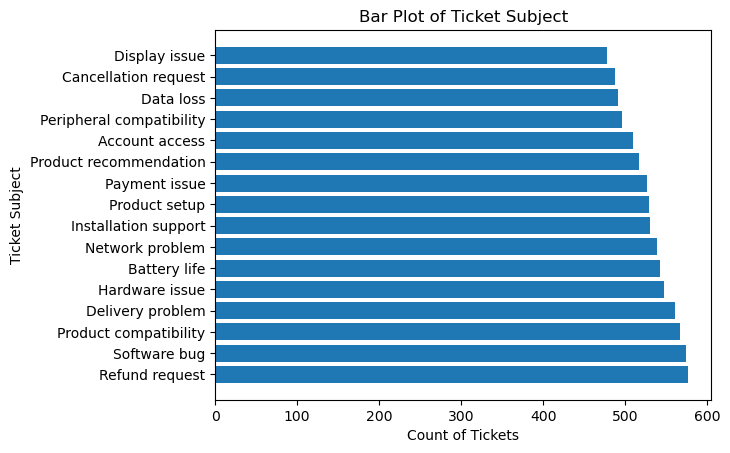

In [22]:
import matplotlib.pyplot as plt

categories = df['Ticket Subject'].value_counts()
cat_keys = categories.index
cat_values = categories.values

plt.barh(cat_keys, cat_values)
plt.title('Bar Plot of Ticket Subject')
plt.xlabel('Count of Tickets')
plt.ylabel('Ticket Subject')
plt.show()

This graph shows the frequency counts for each `Ticket Subject` in the dataset. The counts appear to be fairly uniform and balanced, so I shouldn't need to weight any of the categories in the training set.

##### Graph 2

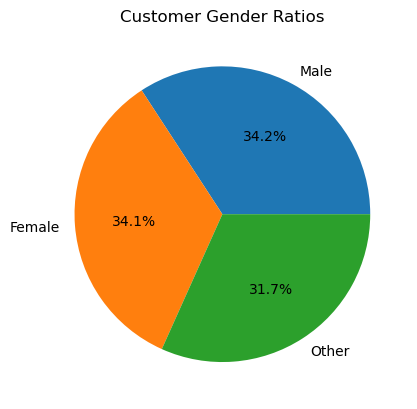

In [23]:
# Get the counts for each category of Customer Gender
gender_counts = df['Customer Gender'].value_counts()

# Create a Pie Chart with the gender_counts
plt.pie(gender_counts, labels=gender_counts.index, autopct='%.1f%%')
plt.title('Customer Gender Ratios')
plt.show()

The above pie chart shows that the genders of the callers are rougly balanced.

##### Graph 3

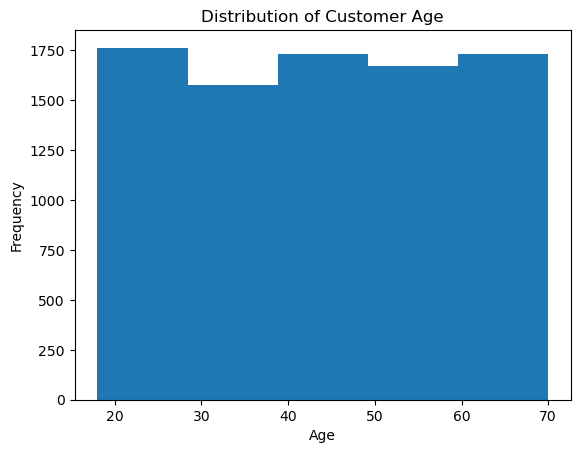

In [24]:
# Create a histogram of Customer Age
plt.hist(df['Customer Age'], bins=5)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

The distribution of Customer Age is relatively flat and follows a uniform distribution.

##### Graph 4

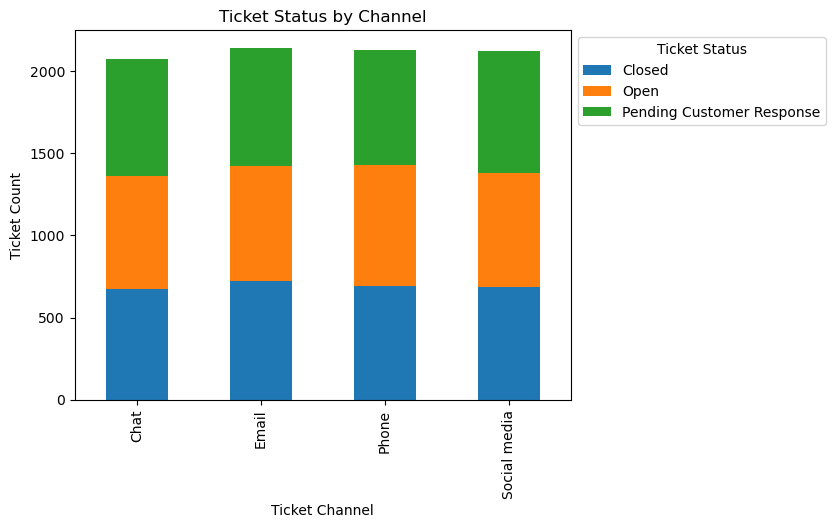

In [25]:
# Group the data by Channel and Status
channel_by_status = df.groupby(['Ticket Channel', 'Ticket Status'])['Ticket ID'].count()

# Create a stacked bar chart
channel_by_status.unstack().plot.bar(stacked=True)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Ticket Status')
plt.title('Ticket Status by Channel')
plt.ylabel('Ticket Count')
plt.show()

Each Channel has roughly the same number of tickets, and there are roughly the same number of tickets of each Status within each column.

# Data Preparation

#### Step 1
Since there appear to be bracketed values from other features within the `Ticket Description` column, I think it would make sense to substitute those fields in place of the features that exist in the dataframe. To do this, I first need to identify the bracketed features within the `Ticket Description`, which I will accomplish using Regular Expressions.

In [26]:
import re

# Use RegEx to capture any bracketed text within each cell
pattern = "{([A-Za-z_]+?)}"   # Matches any single-word strings within curly brackets
bracketed_text = df['Ticket Description'].apply(lambda x: set(re.findall(pattern,x)))
bracketed_text.value_counts()

Ticket Description
{product_purchased}                                    7743
{product_purchased, error_message}                      456
{product_purchased, product_id}                          25
{product_purchased, Product_purchased}                   15
{product_purchased, product}                             10
                                                       ... 
{product_purchased, sizes_for_trucular}                   1
{product_purchased, ProductKey, ProductId, Version}       1
{product_purchased, String, CultureVariant}               1
{product_purchased, citations}                            1
{product_purchased, Product_purchased, product}           1
Name: count, Length: 178, dtype: int64

#### Step 2
The most common bracketed value is some version of `product_purchased`, which I believe corresponds with the `Product Purchased` feature in the orgiginal data. Since none of the other bracketed values appear frequently in the data, I will leave them alone and replace the `product_purchased` variants with the corresponding value from the `Product Purchased` column.

In [27]:
# Convert the Product Purchased and Ticket Description columns to a Numpy array
np_products = df[['Product Purchased', 'Ticket Description']].to_numpy()

# Use list comprehension to substitute the Products in each Ticket Description
text_with_product = [re.sub('{product_purchased}', i[0], i[1], flags=re.IGNORECASE) for i in np_products]

# Use list comprehension to remove any remaining bracketed text
text_without_brackets = [re.sub(pattern, "", i[1], flags=re.IGNORECASE) for i in text_with_product]

# Write the new values to the Ticket Description field
df['Ticket Description'] = text_with_product

# Preview the Ticket Description column
df['Ticket Description'].head()

0    I'm having an issue with the GoPro Hero. Pleas...
1    I'm having an issue with the LG Smart TV. Plea...
2    I'm facing a problem with my Dell XPS. The Del...
3    I'm having an issue with the Microsoft Office....
4    I'm having an issue with the Autodesk AutoCAD....
Name: Ticket Description, dtype: object

#### Step 3
For my analysis, I will only need the `Ticket Description` and `Ticket Subject` columns, so I will create a new dataframe that only includes those two columns.

In [28]:
short_df = df[['Ticket Subject', 'Ticket Description']]
short_df.head()

,Ticket Subject,Ticket Description
0,Product setup,I'm having an issue with the GoPro Hero. Pleas...
1,Peripheral compatibility,I'm having an issue with the LG Smart TV. Plea...
2,Network problem,I'm facing a problem with my Dell XPS. The Del...
3,Account access,I'm having an issue with the Microsoft Office....
4,Data loss,I'm having an issue with the Autodesk AutoCAD....


#### Step 4
Next, I need to convert all of the text in the `Ticket Description` column to lowercase and remove all puncuation and special characters.

In [29]:
import string

# Convert the Ticket Description text to lowercase
lowercase = short_df['Ticket Description'].apply(lambda x: x.lower())

# Remove puncuation and special characters
no_punc = lowercase.apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

# Set the changes to the Ticket Description column and preview the data
short_df.loc[:, 'Ticket Description'] = no_punc
short_df.head()

,Ticket Subject,Ticket Description
0,Product setup,im having an issue with the gopro hero please ...
1,Peripheral compatibility,im having an issue with the lg smart tv please...
2,Network problem,im facing a problem with my dell xps the dell ...
3,Account access,im having an issue with the microsoft office p...
4,Data loss,im having an issue with the autodesk autocad p...


#### Step 5
For the next step, I'll use the `nltk` library to tokenize the `Ticket Description` column and remove stopwords from it.

In [30]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Tokenize the Ticket Description column
token_words = short_df['Ticket Description'].apply(lambda x: word_tokenize(x))

# Get the English stopwords from nltk
eng_stp_words = stopwords.words('english')

# Remove the stopwords from each tokenized Ticket Description
no_stp_words = token_words.apply(lambda x: [word for word in x if word not in eng_stp_words])

no_stp_words.head()

0    [im, issue, gopro, hero, please, assist, billi...
1    [im, issue, lg, smart, tv, please, assist, nee...
2    [im, facing, problem, dell, xps, dell, xps, tu...
3    [im, issue, microsoft, office, please, assist,...
4    [im, issue, autodesk, autocad, please, assist,...
Name: Ticket Description, dtype: object

#### Step 6 
I now need to stem the words, which I'll also accomplish using the `nltk` library.

In [31]:
from nltk.stem.porter import PorterStemmer

# Create the porter and stem the words
porter = PorterStemmer()
stemmed_words = no_stp_words.apply(lambda x: ' '.join([porter.stem(word) for word in x]))

# Preview the stemmed words
stemmed_words.head()

0    im issu gopro hero pleas assist bill zip code ...
1    im issu lg smart tv pleas assist need chang ex...
2    im face problem dell xp dell xp turn work fine...
3    im issu microsoft offic pleas assist problem y...
4    im issu autodesk autocad pleas assist note sel...
Name: Ticket Description, dtype: object

#### Step 7
I will now create a final dataframe that contains the target (`Ticket Subject`) and the stemmed words from the `Ticket Description`.

In [32]:
# Create and preview the final dataframe
tickets = pd.concat([df['Ticket Subject'], stemmed_words], axis=1)
tickets.head()

,Ticket Subject,Ticket Description
0,Product setup,im issu gopro hero pleas assist bill zip code ...
1,Peripheral compatibility,im issu lg smart tv pleas assist need chang ex...
2,Network problem,im face problem dell xp dell xp turn work fine...
3,Account access,im issu microsoft offic pleas assist problem y...
4,Data loss,im issu autodesk autocad pleas assist note sel...


#### Step 8
As my final preparation step, I will split the data into Training and Testing sets.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = TfidfVectorizer()
# vectorizer = CountVectorizer()

# Create the training and testing sets
training_features, testing_features, training_target, testing_target = train_test_split(
    vectorizer.fit_transform(tickets['Ticket Description']),      # Features
    tickets['Ticket Subject'],                                    # Target
    test_size=.2,                                                 # Test set ratio
    random_state=23                                               # Random instance control
)

print(f'Number of training rows: {len(training_target)}')
print(f'Number of testing rows: {len(testing_target)}')

Number of training rows: 6775
Number of testing rows: 1694


My data is now be ready to move to the modelling, which will occur in Milestone 3. My plan is to use Term Frequency-Inverse Document Frequency (TF-IDF) to extract the features from the `Ticket Description` in the training data, then test out a variety of classification models to see which ones are the most effective at accurately predicting the `Ticket Subject` on the testing data.

# Modeling - 1st attempt

#### Step 1: Model Selection

I have selected 3 models to assess:

1. Logistic Regression
2. Decision Tree
3. Multinomial Naive Bayes

I selected these models because they are commonly used for textual classification problems, which is what I am dealing with for my project. I've also selected a range of hyperparameters for the models 

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Create the base model and pipeline
model = LogisticRegression(random_state=31, multi_class='miltinomial')
pipeline = Pipeline([('model', model)])

# Get the prior probabilities for a Naive Bayes model
priors = [i / len(training_target) for i in training_target.value_counts()]

# Create a searchspace for other models to test
search_space = [
    # Logisitc Regression
    {
        'model': [LogisticRegression(random_state=31)],
        'model__penalty': ['l1', 'l2', 'elasticnet', None],
        'model__class_weight': [None, 'balanced']
    }, 

    # Decision Tree
    {
        'model': [DecisionTreeClassifier()],
        'model__max_depth': [10, 15, 20, 25]
    },

    # Multinomial Bayes
    {
        'model': [MultinomialNB()],
        'model__class_prior': [None, priors],
        'model__fit_prior': [True, False],
        'model__alpha': [0.00001, 0.0001, 0.001, 0.1, 1, 10, 100,1000]
    }
]

#### Step 2: Train the model

In [35]:
%%capture --no-stdout

# Create the classifier
classifier = GridSearchCV(pipeline, search_space, verbose=0).fit(training_features, training_target)

#### 3. Evaluate the model

First, I need to determine which model was selected by the Grid Search as the best model.

In [36]:
# Display the best model
classifier.best_estimator_

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None


The Decision Tree Classifier with `max_depth=10` was selected as the best model. Now I need to assess how accurate this classifier was against the testing data.

In [37]:
# Assess the number of predictions the model got right
predictions = classifier.predict(testing_features)
correct_predictions = testing_target == predictions

# Display the predictions
correct_predictions.value_counts().apply(lambda x: f"{x / len(correct_predictions) * 100:.2f}%")

Ticket Subject
False    94.21%
True      5.79%
Name: count, dtype: object

Despite being the best model, the Decision Tree classifier only predicted 5.84% of the target classess correctly, which unfortunately is a worse rate than random chance.

Next, I'll get the Precision, Recall, and F1 Scores for the predictions on the test set.

In [38]:
%%capture --no-stdout

from sklearn.metrics import classification_report

# Print the classification report
print(classification_report(testing_target, predictions))

                          precision    recall  f1-score   support

          Account access       0.00      0.00      0.00        96
            Battery life       0.00      0.00      0.00       105
    Cancellation request       0.00      0.00      0.00       103
               Data loss       0.00      0.00      0.00       101
        Delivery problem       0.00      0.00      0.00       128
           Display issue       0.00      0.00      0.00       114
          Hardware issue       0.00      0.00      0.00       107
    Installation support       1.00      0.01      0.02       108
         Network problem       0.00      0.00      0.00        94
           Payment issue       0.14      0.01      0.02       107
Peripheral compatibility       0.00      0.00      0.00        92
   Product compatibility       0.00      0.00      0.00       119
  Product recommendation       0.00      0.00      0.00       111
           Product setup       0.00      0.00      0.00       113
         

My model had low Precicion, Recall, and F1 Scores in every target class.

Next, I'll visualize a correlation matrix to see where my model is placing its predictions.

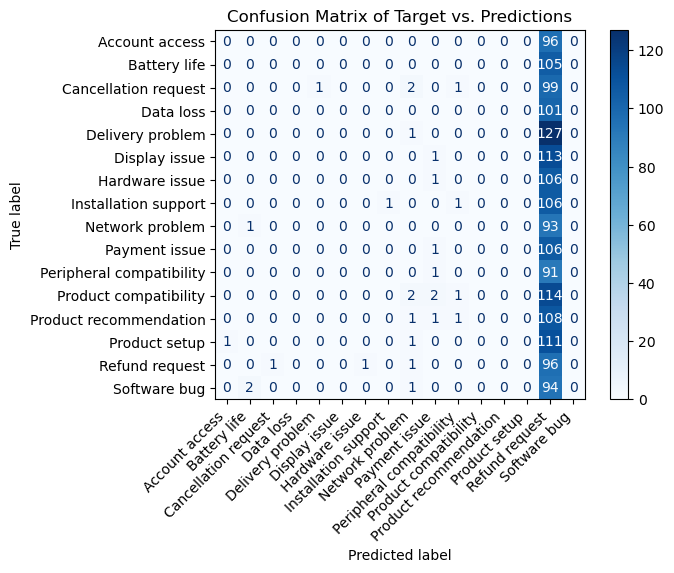

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get the display labels from the model
labels = sorted(set(training_target))

# Plot a heatmap with the confusion matrix of the results
c_matrix = confusion_matrix(testing_target, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=c_matrix, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix of Target vs. Predictions')
plt.show()

The confusion matrix shows that the model predicts that nearly all observations are `Refund requests. 

# Modeling - 2nd Attempt

#### Step 1: Reduce number of target classes

After seeing the low accuracy of my 1st model, I wonder if the poor performance of the model has to due with the large number of classes that are available in my target class (16 possible classes). To see if this is the case, I will remap the target to a reduced number of classes and create a new model. The new remapped target classes will be:

1. Hardward issue
2. Other issue
3. Product inquiry
4. Billing
5. Support request

In [40]:
# Create a dictionary to specifiy how to remap the classes
target_remap_dictionary = {
    'Hardware issue': ['Battery life', 'Display issue', 'Hardware issue'],
    'Other issue': ['Data loss', 'Delivery problem', 'Network problem', 'Software bug'],
    'Product inquiry': ['Peripheral compatibility', 'Product compatibility', 'Product recommendation'],
    'Billing': ['Cancellation request', 'Payment issue', 'Refund request'],
    'Support request': ['Account access', 'Installation support', 'Product setup']
}

# Convert the dictionary to lists for easier iteration
remap_items = target_remap_dictionary.items()
remap_keys = [i[0] for i in remap_items]
remap_values = [i[1] for i in remap_items]

# Create a function that can applied to the dataframe target columns
def remap_target(target):
    index = [target in x for x in remap_values].index(True)
    new_value = remap_keys[index]
    return new_value

# Apply the remapping function to the training and testing target sets
rm_training_target = training_target.apply(lambda x: remap_target(x))
rm_testing_target = testing_target.apply(lambda x: remap_target(x))

#### Step 2: Train the model
Now that the targets have been remapped, I'll create a new model and see if there is any difference in performance.

In [41]:
%%capture --no-stdout

# Create a new classifier and view the best model
rm_classifier = GridSearchCV(pipeline, search_space, verbose=0).fit(training_features, rm_training_target)

#### Step 3: Evaluate the model

In [42]:
# Display the best classifier
rm_classifier.best_estimator_

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,alpha,10
,force_alpha,True
,fit_prior,False
,class_prior,None


This time, the Multinomial Naive Bayes classifier was selected as the best classifier, with an `aplha` of `10` and the `fit_prior` parameter set to `False`.

Now lets see how the new model does against the testing data:

In [43]:
# Assess the number of predictions the model got right
rm_predictions = rm_classifier.predict(testing_features)
correct_rm_predictions = rm_testing_target == rm_predictions

# Display the predictions
correct_rm_predictions.value_counts().apply(lambda x: f"{x / len(correct_rm_predictions) * 100:.2f}%")

Ticket Subject
False    75.38%
True     24.62%
Name: count, dtype: object

The new model did get a higher accuracy score, but it's likely that the boost in accuracy is due to a reduced number of categories to select from. However, the model is now slightly better than random chance at predicting membership in the new target class (24.73% vs. 20% for random chance).

Let's now take a look at the confusion matrix for the remapped data:

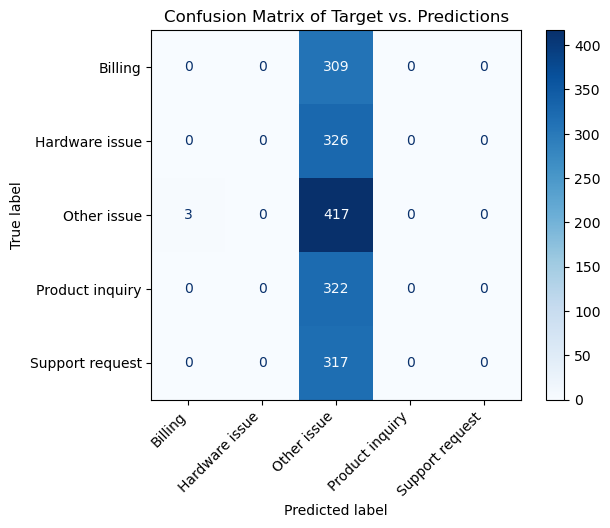

In [44]:
# Get the display labels from the model
rm_labels = sorted(set(rm_training_target))

# Plot a heatmap with the confusion matrix of the results
rm_c_matrix = confusion_matrix(rm_testing_target, rm_predictions)
rm_disp = ConfusionMatrixDisplay(confusion_matrix=rm_c_matrix, display_labels=rm_labels)
rm_disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix of Target vs. Predictions')
plt.show()

Once again, the model is lumping all of its predictions into a single class: the `Other issue` class.

# Modeling - 3rd Attempt

#### Step 1: Reduce the number of features

Its clear that my previous models have not performed well. As a final resort, I will select the top 500 best features in the training dataset and create a new model to see if that improves the performance.

In [45]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Select the best 500 features using chi-squared
chi2_selector = SelectKBest(chi2, k=500)
best_500_model = chi2_selector.fit_transform(training_features, rm_training_target)

# find the indexes of the 500 best features
best_500_indexes = chi2_selector.get_support(indices=True)

# Subset the training and testing features to get just the best 500 features
b500_training_features = training_features[:, best_500_indexes]
b500_testing_features = testing_features[:, best_500_indexes]

#### Step 2: Train the model
Now that I've selected the top 500 features for the Training and Testing sets, I'll create a 3rd model:

In [46]:
%%capture --no-stdout

# Create a new classifier and view the best model
b500_classifier = GridSearchCV(pipeline, search_space, verbose=0).fit(b500_training_features, rm_training_target)

#### Step 3: Evaluate the model

In [47]:
# Display the best classifier
b500_classifier.best_estimator_

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,alpha,0.0001
,force_alpha,True
,fit_prior,True
,class_prior,None


The Multinomial Naive Bayes model was again selected, with an `alpha` value of `0.0001`.

Let's see how the new model does with the testing data:

In [48]:
# Assess the number of predictions the model got right
b500_predictions = b500_classifier.predict(b500_testing_features)
correct_b500_predictions = rm_testing_target == b500_predictions

# Display the predictions
correct_b500_predictions.value_counts().apply(lambda x: f"{x / len(correct_b500_predictions) * 100:.2f}%")

Ticket Subject
False    75.74%
True     24.26%
Name: count, dtype: object

This model was slightly less accurate than the 2nd model, but is still slightly better than random chance.

Let's now take a look at the confusion matrix:

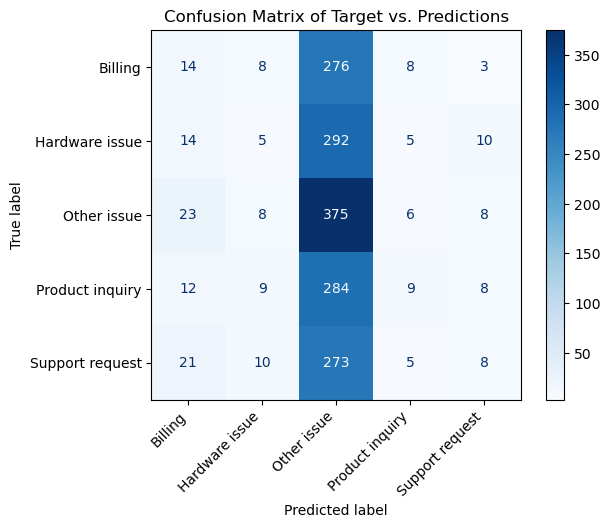

In [49]:
# Plot a heatmap with the confusion matrix of the results
b500_c_matrix = confusion_matrix(rm_testing_target, b500_predictions)
b500_disp = ConfusionMatrixDisplay(confusion_matrix=b500_c_matrix, display_labels=rm_labels)
b500_disp.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.title('Confusion Matrix of Target vs. Predictions')
plt.show()

The 3rd model still predicted membership in the `Other issue` category most of the time, but it did have more diversification of predictions than the 2nd model.

This assignment was challenging, and I unfortunately did not come up with a model that can generate good predictions for my data. It's possible that the data in my dataset is flawed, but I do want to still keep working on understanding textual classification.

<h1 align="center">Final Modifications and Models</h1>

# Modeling - 4th & Final attempt

#### Step 1: Switch to binary classification

For this final attempt, I will turn the classification into a binary classification problem by focusing on a single target category to predict. Specifically, I will attempt to built a model that can classify Hardware Issues.

To do this, I first need to create a copy of the original `tickets` dataframe and remap the categories.

In [50]:
hardware_training_target = rm_training_target == 'Hardware issue'
hardware_testing_target = rm_testing_target == 'Hardware issue'

# Create a copy of the original tickets dataframe, with remapped categories
rs_tickets = tickets.copy()
rs_tickets['Remapped Subject'] = rs_tickets['Ticket Subject'].apply(lambda x: remap_target(x))
rs_tickets['Hardware Issue'] = rs_tickets['Remapped Subject'] == 'Hardware issue'
rs_tickets.drop(['Ticket Subject', 'Remapped Subject'], inplace=True, axis=1)

#### Step 2: Upsample observations 
Since this resulted in a class inbalance, I need to upsample observations of `Hardware issue` in the data. Then, I will split the upsampled data into training and testing sets.

In [51]:
from sklearn.utils import resample

# Upsample where Hardware Issue is True
rs_hardware = rs_tickets[rs_tickets['Hardware Issue']==True]
rs_nonhardware = rs_tickets[rs_tickets['Hardware Issue']==False]
resample_size = len(rs_nonhardware)
upsampled_hardware = resample(rs_hardware, replace=True, n_samples=resample_size, random_state=48)
upsampled_tickets = pd.concat([upsampled_hardware, rs_nonhardware], ignore_index=True)

# # Create the training and testing sets for the upsampled data
rs_training_features, rs_testing_features, rs_training_target, rs_testing_target = train_test_split(
    vectorizer.fit_transform(upsampled_tickets['Ticket Description']),   # Features
    upsampled_tickets['Hardware Issue'],                                 # Target
    test_size=.2,                                                        # Test set ratio
    random_state=23,                                                     # Random instance control
    shuffle=True
)

#### Step 3: Train the model
I'll now create a model and check the accuracy.

In [52]:
%%capture --no-stdout

hardware_classifier = GridSearchCV(pipeline, search_space, verbose=0).fit(rs_training_features, rs_training_target)

#### Step 4: Evaluate the model

In [53]:
hardware_classifier.best_estimator_

,steps,"[('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None


Logistic regression was selected as the best model.

In [54]:
hardware_predictions = hardware_classifier.predict(rs_testing_features)
correct_hardware_predictions = hardware_predictions == rs_testing_target

correct_hardware_predictions.value_counts().apply(lambda x: f"{x / len(correct_hardware_predictions) * 100:.2f}%")

Hardware Issue
True     79.25%
False    20.75%
Name: count, dtype: object

This model predectied membership in the `Hardware issue` class in the testing data with a 79.25% accuracy.

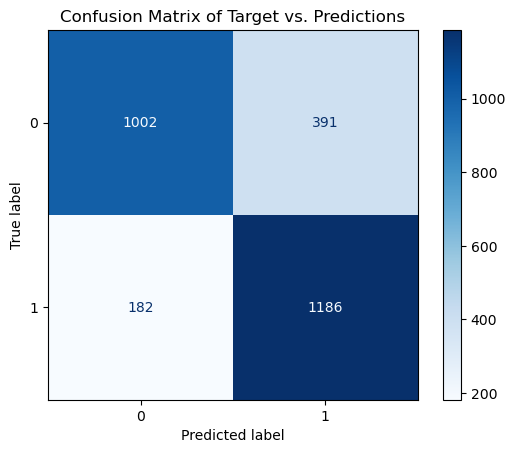

In [55]:
# Plot a heatmap with the confusion matrix of the results
rs_c_matrix = confusion_matrix(rs_testing_target, hardware_predictions)
rs_disp = ConfusionMatrixDisplay(confusion_matrix=rs_c_matrix)
rs_disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix of Target vs. Predictions')
plt.show()

The confusion matrix is much better than the previous models, with predictions falling mostly in line with the true target membership.